In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

In [4]:
#create new dataset
data = {
    'Color': ['Red', 'Red', 'Red', 'Yellow', 'Yellow', 'Yellow', 'Green', 'Green', 'Green'],
    'Shape': ['Round', 'Round', 'Square', 'Round', 'Round', 'Square', 'Round', 'Round', 'Square'],
    'Size': ['Small', 'Large', 'Small', 'Small', 'Large', 'Small', 'Small', 'Large', 'Small'],
    'Label': ['Apple', 'Apple', 'Box', 'Lemon', 'Lemon', 'Box', 'Pear', 'Pear', 'Box']
}
data

{'Color': ['Red',
  'Red',
  'Red',
  'Yellow',
  'Yellow',
  'Yellow',
  'Green',
  'Green',
  'Green'],
 'Shape': ['Round',
  'Round',
  'Square',
  'Round',
  'Round',
  'Square',
  'Round',
  'Round',
  'Square'],
 'Size': ['Small',
  'Large',
  'Small',
  'Small',
  'Large',
  'Small',
  'Small',
  'Large',
  'Small'],
 'Label': ['Apple',
  'Apple',
  'Box',
  'Lemon',
  'Lemon',
  'Box',
  'Pear',
  'Pear',
  'Box']}

In [5]:
#convert dictionary to dataframe
df = pd.DataFrame(data)
df

,Color,Shape,Size,Label
0,Red,Round,Small,Apple
1,Red,Round,Large,Apple
2,Red,Square,Small,Box
3,Yellow,Round,Small,Lemon
4,Yellow,Round,Large,Lemon
5,Yellow,Square,Small,Box
6,Green,Round,Small,Pear
7,Green,Round,Large,Pear
8,Green,Square,Small,Box


In [7]:
#Encode text data to numerical data
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])
df

,Color,Shape,Size,Label
0,1,0,1,0
1,1,0,0,0
2,1,1,1,1
3,2,0,1,2
4,2,0,0,2
5,2,1,1,1
6,0,0,1,3
7,0,0,0,3
8,0,1,1,1


In [10]:
#separate features and target variable 
X = df.drop('Label',axis=1)
y = df['Label']
print("Fetures X:\n",X)
print("\nTarget variable y:\n",y)

Fetures X:
    Color  Shape  Size
0      1      0     1
1      1      0     0
2      1      1     1
3      2      0     1
4      2      0     0
5      2      1     1
6      0      0     1
7      0      0     0
8      0      1     1

Target variable y:
 0    0
1    0
2    1
3    2
4    2
5    1
6    3
7    3
8    1
Name: Label, dtype: int64


In [19]:
#create random forest model
model = RandomForestClassifier(n_estimators=10, random_state=42)
model
# model.fit(X,y) the difference between model and model.fit(X,y) is that model is just an instance of the RandomForestClassifier class, while model.fit(X,y) is the process of training the model on the data X and target variable y. The fit method adjusts the internal parameters of the model based on the provided data, allowing it to learn patterns and make predictions.

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
#tain the model
model.fit(X,y)
#print("The model trained successfully.")

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
#make predictions
sample=[[0, 0, 0]]  # Example input for prediction (Color=Red, Shape=Round, Size=Small)
predictions = model.predict(sample)
print("Predictions:\n",predictions)


Predictions:
 [3]


c:\Users\Dell\anaconda3\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [28]:
#visualize one tree from the random forest
# plt.figure(figsize=(12,8))
# plot_tree(model.estimators_[0], feature_names=X.columns, class_names=le.classes_, filled=True)
# plt.show()

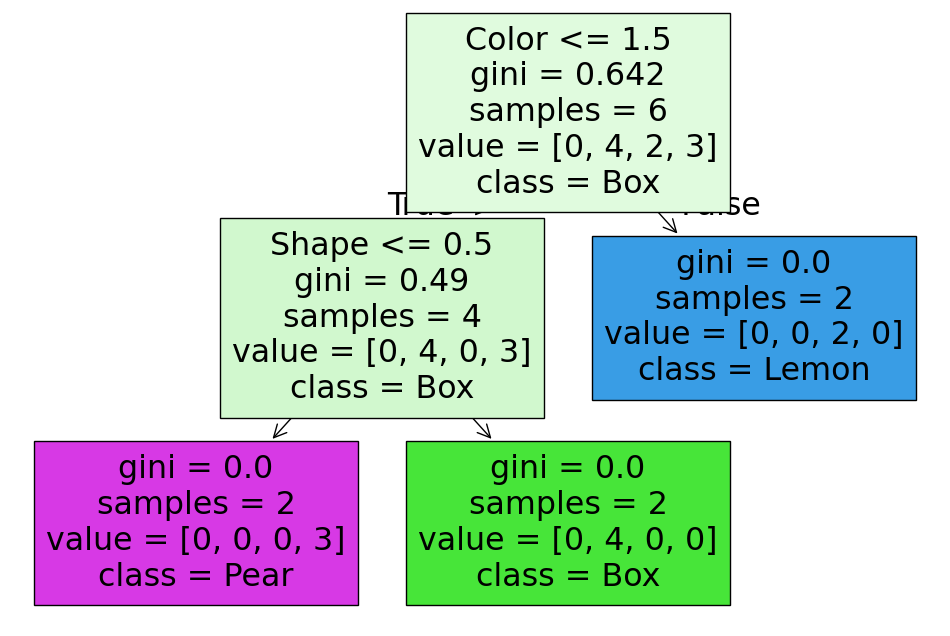

In [27]:
#visualize one tree from the random forest with custom class names

plt.figure(figsize=(12,8))
plot_tree(
	model.estimators_[0],
	feature_names=X.columns,
	class_names=['Apple', 'Box', 'Lemon', 'Pear'],
	filled=True
)
plt.show()